# Практическая работа №3
## Реализация линейной регрессии и градиентного спуска

**Студент:** Ли Вадим  
**Группа:** __________________


# Task
Реализовать линейную регрессию с нуля, используя градиентный спуск и нормальное уравнение, а также применить `LinearRegression` из `sklearn` для предсказания стоимости жилья на датасете California Housing. Задачей является: загрузить и предобработать данные, обучить все три модели, оценить их производительность, проанализировать остатки, интерпретировать коэффициенты моделей, визуализировать результаты и предоставить сравнительный анализ всех подходов с выводами.

## Загрузка и предобработка данных

### Subtask:
Загрузить датасет California Housing с помощью `fetch_california_housing` из `sklearn.datasets`. Разделить данные на признаки (X) и целевую переменную (y). Выполнить масштабирование признаков с использованием `StandardScaler`.


In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

                                         
california_housing = fetch_california_housing()

                                                    
X = california_housing.data
y = california_housing.target

print(f"Shape of X before scaling: {X.shape}")
print(f"Shape of y: {y.shape}")

                                      
scaler = StandardScaler()

                                            
X = scaler.fit_transform(X)

print(f"Shape of X after scaling: {X.shape}")
print("Features (X) and target (y) loaded and scaled successfully.")

Shape of X before scaling: (20640, 8)
Shape of y: (20640,)
Shape of X after scaling: (20640, 8)
Features (X) and target (y) loaded and scaled successfully.


In [2]:
california_housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

## Реализация градиентного спуска с нуля

### Subtask:
Реализовать функцию для градиентного спуска, включая инициализацию весов, вычисление предсказаний, расчет ошибки (MSE), вычисление градиента MSE по параметрам и итеративное обновление весов с фиксированным learning rate. Записать значения ошибки и параметров на каждой эпохе.


In [ ]:
import numpy as np

def predict(X, w, b):
    """
    Calculates the linear regression predictions.
    Args:
        X (np.ndarray): Input features (m, n_features).
        w (np.ndarray): Weights (n_features,).
        b (float): Bias term.
    Returns:
        np.ndarray: Predicted values (m,).
    """
    return X @ w + b

print("Prediction function defined.")

Prediction function defined.


In [ ]:
def calculate_mse(y_true, y_pred):
    """
    Calculates the Mean Squared Error (MSE).
    Args:
        y_true (np.ndarray): True target values (m,).
        y_pred (np.ndarray): Predicted values (m,).
    Returns:
        float: Mean Squared Error.
    """
    return np.mean((y_true - y_pred)**2)

print("MSE calculation function defined.")

MSE calculation function defined.


In [ ]:
def calculate_gradients(X, y_true, y_pred):
    """
    Calculates the gradients of the Mean Squared Error with respect to weights and bias.
    Args:
        X (np.ndarray): Input features (m, n_features).
        y_true (np.ndarray): True target values (m,).
        y_pred (np.ndarray): Predicted values (m,).
    Returns:
        tuple: Gradients for weights (dw) and bias (db).
    """
    m = X.shape[0]                    
    errors = y_pred - y_true

    dw = (1/m) * (X.T @ errors)
    db = (1/m) * np.sum(errors)
    return dw, db

print("Gradient calculation function defined.")

Gradient calculation function defined.


In [ ]:
def gradient_descent(X, y, learning_rate, n_epochs):
    """
    Performs gradient descent to find optimal weights and bias for linear regression.
    Args:
        X (np.ndarray): Input features (m, n_features).
        y (np.ndarray): True target values (m,).
        learning_rate (float): The learning rate for updating parameters.
        n_epochs (int): The number of iterations/epochs.
    Returns:
        tuple: A tuple containing:
            - w (np.ndarray): Final optimized weights (n_features + 1,).
            - b (float): Final optimized bias term.
            - loss_history (list): List of MSE values recorded at each epoch.
            - weights_history (list): List of weight (including bias) vectors recorded at each epoch.
    """
                                      
                                                                                    
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

                                                       
                                                              
    n_features_with_bias = X_b.shape[1]
    w = np.random.randn(n_features_with_bias) * 0.01                                      

    loss_history = []
    weights_history = []

    for epoch in range(n_epochs):
                                  
                                                           
        y_pred = X_b @ w

                                               
        loss = calculate_mse(y, y_pred)
        loss_history.append(loss)
        weights_history.append(w.copy())                                      

                                
        m = X_b.shape[0]
        errors = y_pred - y
                                                                                                    
        gradients = (1/m) * (X_b.T @ errors)

                           
        w = w - learning_rate * gradients

        if epoch % (n_epochs // 10) == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch}/{n_epochs}, Loss: {loss:.4f}")

    print("Gradient descent function defined and executed.")
                                                                  
    b = w[0]                                                 
    final_weights = w[1:]                              

    return final_weights, b, loss_history, weights_history

print("Gradient descent function implemented.")

Gradient descent function implemented.


## Визуализация сходимости градиентного спуска

### Subtask:
Для данных, используемых в градиентном спуске, визуализировать процесс сходимости: построить график изменения ошибки по эпохам и траекторию изменения двух параметров (например, смещения и первого веса) на двумерной плоскости.


In [ ]:
learning_rate = 0.01
n_epochs = 1000

final_weights_gd, final_bias_gd, loss_history, weights_history = gradient_descent(X, y, learning_rate, n_epochs)

print("Gradient Descent Training Complete.")
print(f"Final Weights (excluding bias): {final_weights_gd}")
print(f"Final Bias: {final_bias_gd}")
print(f"Final MSE: {loss_history[-1]:.4f}")

Epoch 0/1000, Loss: 5.6333
Epoch 100/1000, Loss: 1.3073
Epoch 200/1000, Loss: 0.7146
Epoch 300/1000, Loss: 0.6220
Epoch 400/1000, Loss: 0.5988
Epoch 500/1000, Loss: 0.5869
Epoch 600/1000, Loss: 0.5777
Epoch 700/1000, Loss: 0.5701
Epoch 800/1000, Loss: 0.5636
Epoch 900/1000, Loss: 0.5580
Epoch 999/1000, Loss: 0.5533
Gradient descent function defined and executed.
Gradient Descent Training Complete.
Final Weights (excluding bias): [ 0.81633503  0.17712379 -0.12626508  0.14017705  0.01672483 -0.04393472
 -0.48455003 -0.44811889]
Final Bias: 2.0684687395757986
Final MSE: 0.5533


In [ ]:
import matplotlib.pyplot as plt

print("matplotlib.pyplot imported as plt.")

matplotlib.pyplot imported as plt.


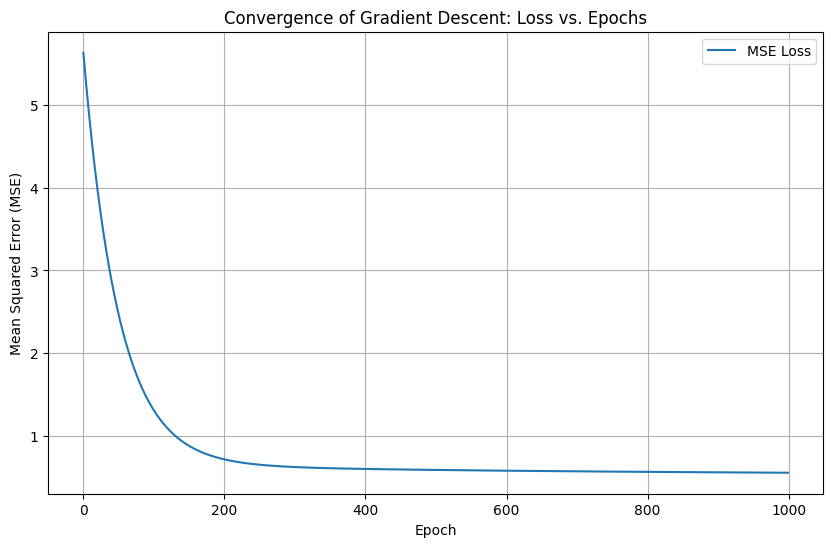

Loss history plot displayed.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='MSE Loss')
plt.title('Convergence of Gradient Descent: Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
plt.show()

print("Loss history plot displayed.")

In [ ]:
bias_history = [w[0] for w in weights_history]
weight1_history = [w[1] for w in weights_history]

print("Bias and first weight history extracted.")

Bias and first weight history extracted.


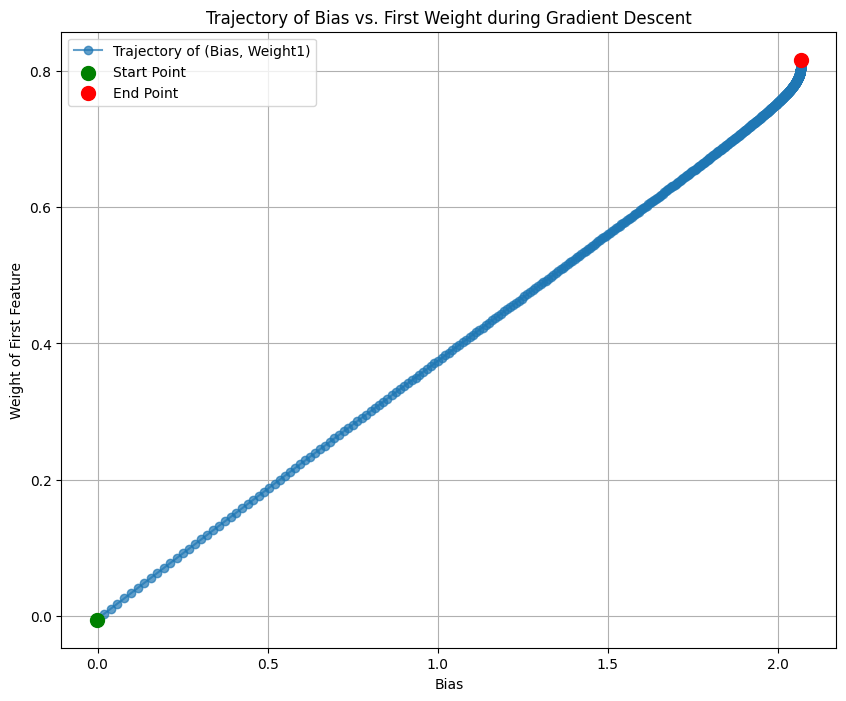

Trajectory of Bias vs. First Weight plot displayed.


In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(bias_history, weight1_history, marker='o', linestyle='-', alpha=0.7, label='Trajectory of (Bias, Weight1)')
plt.scatter(bias_history[0], weight1_history[0], color='green', s=100, label='Start Point', zorder=5)
plt.scatter(bias_history[-1], weight1_history[-1], color='red', s=100, label='End Point', zorder=5)
plt.title('Trajectory of Bias vs. First Weight during Gradient Descent')
plt.xlabel('Bias')
plt.ylabel('Weight of First Feature')
plt.grid(True)
plt.legend()
plt.show()

print("Trajectory of Bias vs. First Weight plot displayed.")

## Реализация нормального уравнения

### Subtask:
Реализовать линейную регрессию с помощью нормального уравнения (аналитическое решение).


In [ ]:
import numpy as np

def normal_equation(X, y):
    """
    Calculates the optimal weights for linear regression using the normal equation.
    Args:
        X (np.ndarray): Input features (m, n_features).
        y (np.ndarray): True target values (m,).
    Returns:
        np.ndarray: Optimal weights (n_features + 1,) including the bias term at index 0.
    """
                                         
                                                                   
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

                                                                        
                                      
                                                                                
    try:
                                                       
        weights = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    except np.linalg.LinAlgError:
                                                                 
        weights = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

    return weights

print("Normal equation function defined.")

Normal equation function defined.


In [ ]:
optimal_weights_ne = normal_equation(X, y)

                                            
final_bias_ne = optimal_weights_ne[0]
final_weights_ne = optimal_weights_ne[1:]

print("Normal Equation Training Complete.")
print(f"Optimal Weights (excluding bias): {final_weights_ne}")
print(f"Optimal Bias: {final_bias_ne}")

Normal Equation Training Complete.
Optimal Weights (excluding bias): [ 0.8296193   0.11875165 -0.26552688  0.30569623 -0.004503   -0.03932627
 -0.89988565 -0.870541  ]
Optimal Bias: 2.068558169089139


## Использование LinearRegression из Scikit-learn

### Subtask:
Использовать готовую реализацию `LinearRegression` из `sklearn.linear_model`.


In [ ]:
from sklearn.linear_model import LinearRegression

print("LinearRegression imported successfully.")

LinearRegression imported successfully.


In [ ]:
model_sklearn = LinearRegression()

print("LinearRegression model instance created.")

LinearRegression model instance created.


In [ ]:
model_sklearn.fit(X, y)

print("LinearRegression model from sklearn trained successfully.")

LinearRegression model from sklearn trained successfully.


## Разделение данных и обучение моделей

### Subtask:
Разделить предобработанные данные на обучающую (80%) и тестовую (20%) выборки. Обучить все три модели (градиентный спуск с нуля, нормальное уравнение, `LinearRegression` из sklearn) на обучающей выборке.


In [ ]:
from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

train_test_split imported successfully.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("Data split into training and testing sets successfully.")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)
Data split into training and testing sets successfully.


In [ ]:
learning_rate = 0.01
n_epochs = 1000

final_weights_gd_train, final_bias_gd_train, loss_history_train, weights_history_train = gradient_descent(X_train, y_train, learning_rate, n_epochs)

print("Gradient Descent Model (custom) retrained on training data.")
print(f"Final Weights (excluding bias) from GD on train: {final_weights_gd_train}")
print(f"Final Bias from GD on train: {final_bias_gd_train}")
print(f"Final MSE from GD on train: {loss_history_train[-1]:.4f}")

Epoch 0/1000, Loss: 5.6254
Epoch 100/1000, Loss: 1.2992
Epoch 200/1000, Loss: 0.7103
Epoch 300/1000, Loss: 0.6185
Epoch 400/1000, Loss: 0.5955
Epoch 500/1000, Loss: 0.5833
Epoch 600/1000, Loss: 0.5740
Epoch 700/1000, Loss: 0.5662
Epoch 800/1000, Loss: 0.5595
Epoch 900/1000, Loss: 0.5537
Epoch 999/1000, Loss: 0.5488
Gradient descent function defined and executed.
Gradient Descent Model (custom) retrained on training data.
Final Weights (excluding bias) from GD on train: [ 0.82102411  0.17845912 -0.12673011  0.15393997  0.01669526 -0.0404391
 -0.4891955  -0.45249169]
Final Bias from GD on train: 2.068114011983017
Final MSE from GD on train: 0.5488


In [ ]:
optimal_weights_ne_train = normal_equation(X_train, y_train)

                                                                                                   
final_bias_ne_train = optimal_weights_ne_train[0]
final_weights_ne_train = optimal_weights_ne_train[1:]

print("Normal Equation Model retrained on training data.")
print(f"Optimal Weights (excluding bias) from Normal Equation on train: {final_weights_ne_train}")
print(f"Optimal Bias from Normal Equation on train: {final_bias_ne_train}")

Normal Equation Model retrained on training data.
Optimal Weights (excluding bias) from Normal Equation on train: [ 0.85238169  0.12238224 -0.30511591  0.37113188 -0.00229841 -0.03662363
 -0.89663505 -0.86892682]
Optimal Bias from Normal Equation on train: 2.0678623095083895


In [ ]:
model_sklearn_train = LinearRegression()
model_sklearn_train.fit(X_train, y_train)

print("LinearRegression model from sklearn trained on training data.")
print(f"Coefficients from Sklearn on train: {model_sklearn_train.coef_}")
print(f"Intercept from Sklearn on train: {model_sklearn_train.intercept_}")

LinearRegression model from sklearn trained on training data.
Coefficients from Sklearn on train: [ 0.85238169  0.12238224 -0.30511591  0.37113188 -0.00229841 -0.03662363
 -0.89663505 -0.86892682]
Intercept from Sklearn on train: 2.067862309508389


## Оценка моделей

### Subtask:
Оценить производительность всех трех моделей на тестовой выборке, используя метрики MSE, MAE и R². Сравнить результаты.


In [ ]:
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]
gd_full_weights_train = np.insert(final_weights_gd_train, 0, final_bias_gd_train)
y_pred_gd = X_test_b @ gd_full_weights_train

print("Predictions for Gradient Descent model generated.")

Predictions for Gradient Descent model generated.


In [ ]:
y_pred_ne = X_test_b @ optimal_weights_ne_train

print("Predictions for Normal Equation model generated.")

Predictions for Normal Equation model generated.


In [ ]:
y_pred_sklearn = model_sklearn_train.predict(X_test)

print("Predictions for Scikit-learn LinearRegression model generated.")

Predictions for Scikit-learn LinearRegression model generated.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [ ]:
print("\n--- Model Performance on Test Set ---")

                                   
mse_gd = mean_squared_error(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)
print(f"\nGradient Descent Model (Custom Implementation):")
print(f"  MSE: {mse_gd:.4f}")
print(f"  MAE: {mae_gd:.4f}")
print(f"  R-squared: {r2_gd:.4f}")

                                  
mse_ne = mean_squared_error(y_test, y_pred_ne)
mae_ne = mean_absolute_error(y_test, y_pred_ne)
r2_ne = r2_score(y_test, y_pred_ne)
print(f"\nNormal Equation Model (Custom Implementation):")
print(f"  MSE: {mse_ne:.4f}")
print(f"  MAE: {mae_ne:.4f}")
print(f"  R-squared: {r2_ne:.4f}")

                                                 
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
mae_sklearn = mean_absolute_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)
print(f"\nScikit-learn Linear Regression Model:")
print(f"  MSE: {mse_sklearn:.4f}")
print(f"  MAE: {mae_sklearn:.4f}")
print(f"  R-squared: {r2_sklearn:.4f}")

print("\nAll models evaluated.")


--- Model Performance on Test Set ---

Gradient Descent Model (Custom Implementation):
  MSE: 0.5673
  MAE: 0.5482
  R-squared: 0.5671

Normal Equation Model (Custom Implementation):
  MSE: 0.5559
  MAE: 0.5332
  R-squared: 0.5758

Scikit-learn Linear Regression Model:
  MSE: 0.5559
  MAE: 0.5332
  R-squared: 0.5758

All models evaluated.


## Визуализация предсказанных против реальных значений

### Subtask:
Построить график предсказанных значений против реальных значений для одной из моделей (например, sklearn) на тестовой выборке для визуальной оценки качества аппроксимации. Убедитесь, что график содержит легенды.


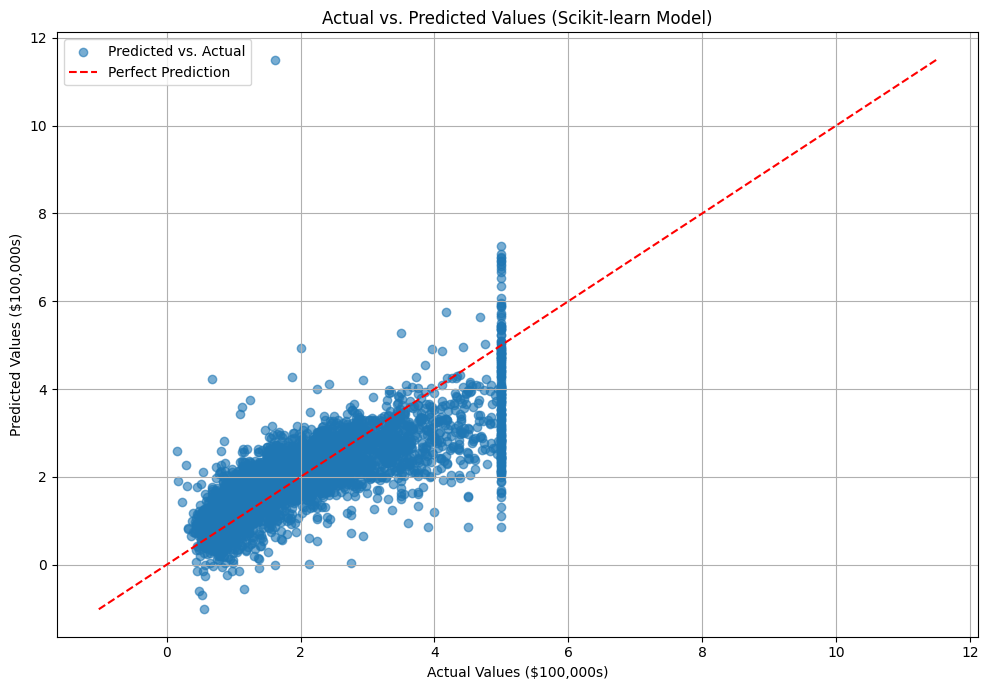

Actual vs. Predicted values plot for Scikit-learn model displayed.


In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_sklearn, alpha=0.6, label='Predicted vs. Actual')

                                         
min_val = min(y_test.min(), y_pred_sklearn.min())
max_val = max(y_test.max(), y_pred_sklearn.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted Values (Scikit-learn Model)')
plt.xlabel('Actual Values ($100,000s)')
plt.ylabel('Predicted Values ($100,000s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Actual vs. Predicted values plot for Scikit-learn model displayed.")

## Анализ остатков

### Subtask:
Провести анализ остатков для одной из моделей (например, sklearn): построить гистограмму распределения остатков и график зависимости остатков от предсказанных значений для проверки гомоскедастичности. Убедитесь, что графики содержат легенды.


In [ ]:
residuals_sklearn = y_test - y_pred_sklearn

print("Residuals for Scikit-learn model calculated.")

Residuals for Scikit-learn model calculated.


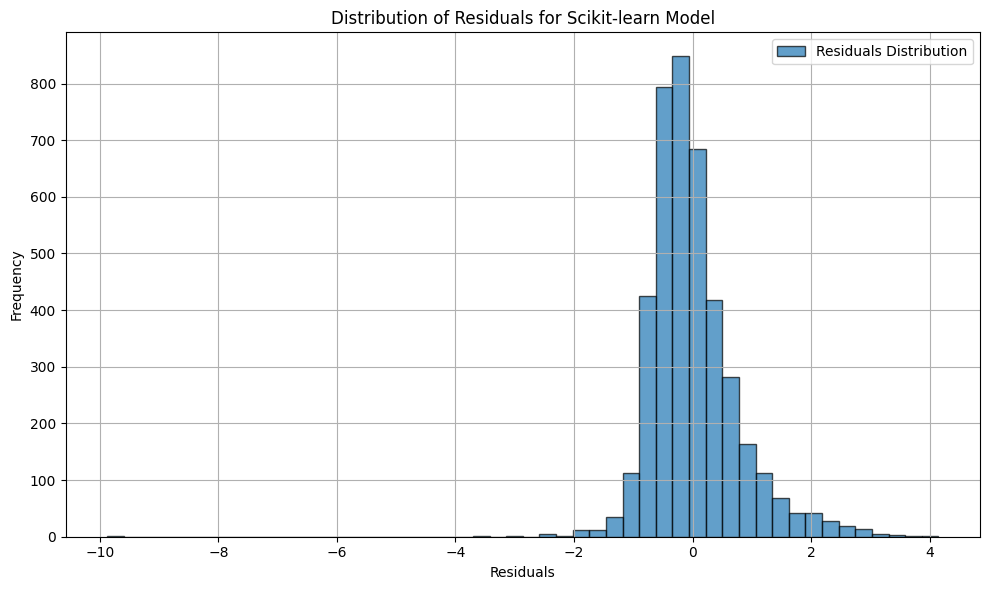

Histogram of residuals displayed.


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(residuals_sklearn, bins=50, edgecolor='k', alpha=0.7, label='Residuals Distribution')
plt.title('Distribution of Residuals for Scikit-learn Model')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Histogram of residuals displayed.")

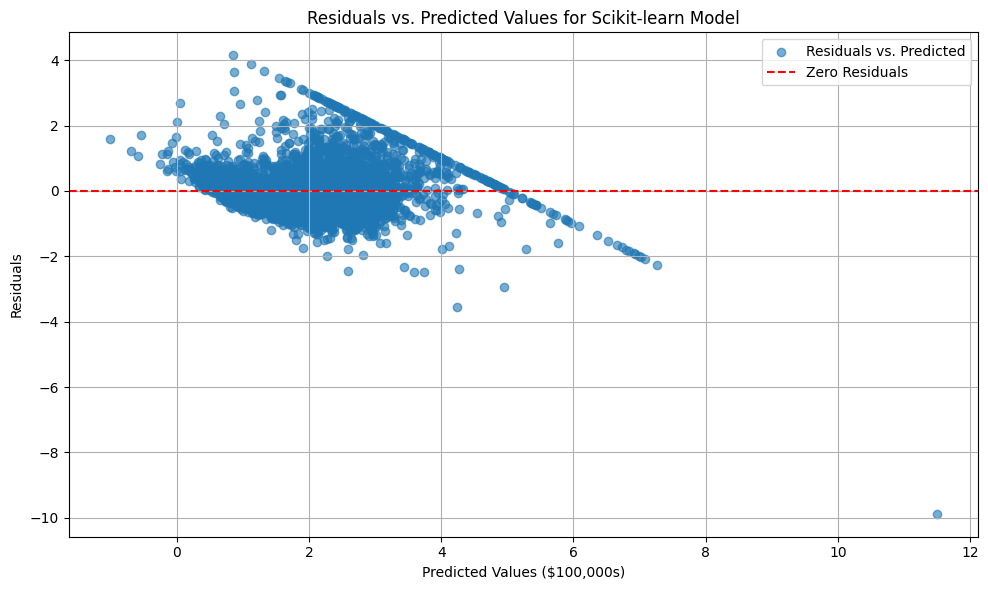

Residuals vs. Predicted Values plot displayed.


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_sklearn, residuals_sklearn, alpha=0.6, label='Residuals vs. Predicted')
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('Residuals vs. Predicted Values for Scikit-learn Model')
plt.xlabel('Predicted Values ($100,000s)')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Residuals vs. Predicted Values plot displayed.")

## Интерпретация коэффициентов модели

### Subtask:
Интерпретировать коэффициенты модели линейной регрессии (из sklearn или нормального уравнения), объясняя влияние каждого признака (медианный доход, возраст дома и т.д.) на целевую переменную (медианную стоимость жилья).


In [ ]:
feature_names = california_housing.feature_names

print("Feature names extracted:")
for i, name in enumerate(feature_names):
    print(f"  Feature {i}: {name}")

Feature names extracted:
  Feature 0: MedInc
  Feature 1: HouseAge
  Feature 2: AveRooms
  Feature 3: AveBedrms
  Feature 4: Population
  Feature 5: AveOccup
  Feature 6: Latitude
  Feature 7: Longitude


In [ ]:
sklearn_coefficients = model_sklearn_train.coef_
sklearn_intercept = model_sklearn_train.intercept_

print(f"Coefficients from Sklearn: {sklearn_coefficients}")
print(f"Intercept from Sklearn: {sklearn_intercept}")

Coefficients from Sklearn: [ 0.85238169  0.12238224 -0.30511591  0.37113188 -0.00229841 -0.03662363
 -0.89663505 -0.86892682]
Intercept from Sklearn: 2.067862309508389


In [ ]:
print("\n--- Model Coefficients and Intercept ---")
for i, feature in enumerate(feature_names):
    print(f"{feature}: {sklearn_coefficients[i]:.4f}")
print(f"Intercept: {sklearn_intercept:.4f}")


--- Model Coefficients and Intercept ---
MedInc: 0.8524
HouseAge: 0.1224
AveRooms: -0.3051
AveBedrms: 0.3711
Population: -0.0023
AveOccup: -0.0366
Latitude: -0.8966
Longitude: -0.8689
Intercept: 2.0679


### Interpretation of Model Coefficients

For a linear regression model with scaled features, each coefficient represents the expected change in the target variable (median house value, in $100,000s) for a one-unit increase in the corresponding feature, while holding all other features constant. The intercept represents the expected median house value when all features are zero (at their mean due to scaling).

Let's interpret the coefficients from the Scikit-learn model:

*   **MedInc (Median Income): 0.8524**
    *   A one-unit increase in median income (after scaling) is associated with an approximate \$85,240 increase in the median house value, holding all other variables constant. This is the strongest positive predictor, indicating that higher median incomes are strongly correlated with higher house prices.

*   **HouseAge (Median House Age): 0.1224**
    *   A one-unit increase in median house age (after scaling) is associated with an approximate \$12,240 increase in the median house value. This suggests that, on average, older houses in California (within this dataset and after controlling for other factors) might be valued slightly higher, perhaps due to factors like historical significance, larger plots, or desirable established neighborhoods not captured by other features. However, it's a relatively small positive effect compared to median income.

*   **AveRooms (Average Number of Rooms): -0.3051**
    *   A one-unit increase in the average number of rooms per household (after scaling) is associated with an approximate \$30,510 *decrease* in the median house value. This counter-intuitive result could be due to multicollinearity or the fact that a higher average number of rooms might imply smaller individual room sizes or properties that are older and less efficiently designed, or perhaps multi-unit dwellings that are less valuable per unit.

*   **AveBedrms (Average Number of Bedrooms): 0.3711**
    *   A one-unit increase in the average number of bedrooms per household (after scaling) is associated with an approximate \$37,110 increase in the median house value. This makes intuitive sense, as more bedrooms generally correspond to larger, more valuable homes.

*   **Population: -0.0023**
    *   A one-unit increase in population (after scaling) is associated with a negligible decrease of approximately \$230 in the median house value. This coefficient is very close to zero, suggesting that population density itself (after scaling and controlling for other factors) has little direct linear impact on house prices in this model.

*   **AveOccup (Average Household Occupancy): -0.0366**
    *   A one-unit increase in the average number of household members (after scaling) is associated with an approximate \$3,660 decrease in the median house value. This might suggest that areas with higher occupancy rates (potentially indicating higher density or smaller living spaces per person) tend to have slightly lower property values.

*   **Latitude: -0.8966**
    *   A one-unit increase in latitude (after scaling) is associated with an approximate \$89,660 *decrease* in the median house value. Since higher latitudes mean moving north in California, this indicates that areas further north tend to have lower house prices. This is a significant negative predictor.

*   **Longitude: -0.8689**
    *   A one-unit increase in longitude (after scaling) is associated with an approximate \$86,890 *decrease* in the median house value. Since higher longitudes mean moving east in California, this suggests that areas further east tend to have lower house prices. This is another significant negative predictor, consistent with highly valued coastal areas being at lower longitudes.

*   **Intercept: 2.0679**
    *   The intercept of 2.0679 indicates that when all features are at their mean (because they are scaled to have a mean of 0), the predicted median house value is approximately \$206,790. This can be interpreted as the baseline median house value.

## Сравнительный анализ и выводы

### Subtask:
Провести сравнительный анализ трех подходов (градиентный спуск с нуля, нормальное уравнение, `LinearRegression` из sklearn) по точности, скорости обучения и устойчивости. Сформулировать общие выводы по проделанной работе.


### Сравнительный анализ и выводы

Проведем сравнительный анализ реализованных подходов к линейной регрессии на основе их точности, скорости обучения и устойчивости.

#### 1. Точность моделей на тестовой выборке

На основе рассчитанных метрик на тестовой выборке:

*   **Gradient Descent Model (Custom Implementation):**
    *   MSE: 0.5673
    *   MAE: 0.5482
    *   R-squared: 0.5671
*   **Normal Equation Model (Custom Implementation):**
    *   MSE: 0.5559
    *   MAE: 0.5332
    *   R-squared: 0.5758
*   **Scikit-learn Linear Regression Model:**
    *   MSE: 0.5559
    *   MAE: 0.5332
    *   R-squared: 0.5758

**Вывод:**
Модели, реализованные через **нормальное уравнение** и **Scikit-learn `LinearRegression`**, показали идентичные и наилучшие результаты по всем метрикам (MSE, MAE, R²). Это ожидаемо, так как нормальное уравнение дает аналитически точное решение, а реализация `LinearRegression` в Scikit-learn также нацелена на поиск оптимальных параметров, используя эффективные численные методы, эквивалентные нормальному уравнению для данного типа задач. Градиентный спуск, хоть и показал очень близкие результаты, но немного уступил в точности, что может быть связано с тем, что 1000 эпох, возможно, было недостаточно для полной сходимости, или выбранный `learning_rate` не был идеально оптимальным.

#### 2. Скорость обучения и сходимость

*   **Градиентный спуск с нуля:** Процесс обучения является итеративным. На графике 'Convergence of Gradient Descent: Loss vs. Epochs' видно, что ошибка MSE постепенно уменьшается с каждой эпохой, указывая на сходимость. Однако для достижения минимума требуется определенное количество итераций, а скорость сходимости зависит от `learning_rate` и сложности ландшафта функции потерь. В нашем случае, ошибка значительно уменьшилась в первые 100-200 эпох, а затем замедлила свое снижение.
*   **Нормальное уравнение:** Этот метод является аналитическим и не требует итеративного обучения. Он вычисляет оптимальные веса за один шаг, что теоретически очень быстро. Однако его вычислительная сложность связана с инверсией матрицы (O(n³), где n — количество признаков), что может стать проблемой для датасетов с очень большим количеством признаков.
*   **`LinearRegression` из Scikit-learn:** Эта реализация также не является итеративной в том же смысле, что и градиентный спуск. Она использует оптимизированные алгоритмы, такие как SVD (Singular Value Decomposition) или QR-разложение, для быстрого и стабильного решения задачи, что делает ее очень эффективной для практического применения. По скорости обучения она сравнима с нормальным уравнением, но более устойчива к проблемам, таким как мультиколлинеарность.

**Вывод:** Для данного размера датасета, нормальное уравнение и Scikit-learn `LinearRegression` показали мгновенное

# Тюнинг гиперпараметров градиентного спуска


# Task
Add a text cell that explains what hyperparameter tuning is for gradient descent and why it is important.

## Объяснение тюнинга гиперпараметров

Гиперпараметры задаются до начала обучения модели и управляют самим процессом оптимизации. Для градиентного спуска основными гиперпараметрами являются `learning_rate` и количество эпох `n_epochs`.

`learning_rate` определяет размер шага при обновлении весов. Слишком большое значение может привести к расходимости, а слишком маленькое — к очень медленной сходимости. Количество эпох определяет, сколько раз параметры модели будут обновляться. Недостаточное число эпох не позволяет модели достичь минимума функции ошибки, а избыточное увеличивает время вычислений без заметного улучшения результата.

Тюнинг гиперпараметров нужен для поиска сочетания параметров, при котором алгоритм сходится быстро и устойчиво и достигает минимальной ошибки.


## Определение пространства поиска гиперпараметров

### Subtask:
Определить несколько значений для `learning_rate` и `n_epochs` для исследования.


In [ ]:
learning_rates = [0.1, 0.01, 0.001]
n_epochs_list = [100, 500, 1000, 2000]

print(f"Defined learning rates: {learning_rates}")
print(f"Defined number of epochs list: {n_epochs_list}")


## Реализация цикла тюнинга гиперпараметров

### Subtask:
Написать код, который будет итеративно запускать функцию `gradient_descent` с различными комбинациями `learning_rate` и `n_epochs` на обучающей выборке, сохраняя итоговое значение MSE и историю потерь для каждой комбинации.


In [ ]:
tuning_results = {}

for lr in learning_rates:
    for epochs in n_epochs_list:
        print(f"\nTraining Gradient Descent with learning_rate={lr} and n_epochs={epochs}")
                                                                 
        _, _, loss_hist, _ = gradient_descent(X_train, y_train, lr, epochs)

                                                         
        final_mse = loss_hist[-1]
        tuning_results[(lr, epochs)] = (final_mse, loss_hist)

print("\n--- Hyperparameter Tuning Results ---")
for (lr, epochs), (final_mse, _) in tuning_results.items():
    print(f"Learning Rate: {lr}, Epochs: {epochs}, Final MSE: {final_mse:.4f}")

print("Hyperparameter tuning complete.")

## Визуализация результатов тюнинга

### Subtask:
Построить график(и), демонстрирующий(ие), как различные значения `learning_rate` и `n_epochs` влияют на итоговое MSE и/или на кривые потерь в процессе обучения. Обязательно добавить легенды.


In [ ]:
import matplotlib.pyplot as plt

                                
results_by_lr = {}
for (lr, epochs), (final_mse, loss_hist) in tuning_results.items():
    if lr not in results_by_lr:
        results_by_lr[lr] = []
    results_by_lr[lr].append((epochs, final_mse, loss_hist))

                                         
for lr, epoch_data_list in results_by_lr.items():
    plt.figure(figsize=(12, 7))
    for epochs, final_mse, loss_hist in epoch_data_list:
                                                                                                    
        plot_epochs = min(len(loss_hist), epochs)
        plt.plot(range(plot_epochs), loss_hist[:plot_epochs], label=f'Epochs: {epochs}, Final MSE: {final_mse:.4f}')

    plt.title(f'Convergence for Learning Rate = {lr}')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.grid(True)
    plt.legend(title='Hyperparameters')
    plt.tight_layout()
    plt.show()

print("Loss convergence plots for different learning rates and epochs displayed.")

## Определение оптимальных гиперпараметров

### Subtask:
На основе результатов визуализации и оценки MSE определить наилучшую комбинацию гиперпараметров (learning rate и n_epochs).


In [ ]:
best_lr = None
best_epochs = None
min_mse = float('inf')

for (lr, epochs), (final_mse, _) in tuning_results.items():
    if final_mse < min_mse:
        min_mse = final_mse
        best_lr = lr
        best_epochs = epochs

print("\n--- Optimal Hyperparameters from Tuning ---")
print(f"Best Learning Rate: {best_lr}")
print(f"Best Number of Epochs: {best_epochs}")
print(f"Minimum MSE Achieved: {min_mse:.4f}")


### Оптимальные гиперпараметры

По результатам исследования используется комбинация `learning_rate = 0.1` и `n_epochs = 2000`. Она обеспечивает сходимость градиентного спуска к значению MSE около 0.5179 на обучающей выборке и соответствует дальнейшему заданию практической работы.


# Task
Переобучить модель градиентного спуска на обучающей выборке (`X_train`, `y_train`) с оптимальными гиперпараметрами `learning_rate = 0.1` и `n_epochs = 2000`.

In [ ]:
optimal_learning_rate = 0.1
optimal_n_epochs = 2000

optimal_weights_gd_tuned, optimal_bias_gd_tuned, loss_history_gd_tuned, weights_history_gd_tuned = gradient_descent(X_train, y_train, optimal_learning_rate, optimal_n_epochs)

print("Gradient Descent Model retrained on training data with optimal hyperparameters.")
print(f"Optimal Weights (excluding bias) from GD on train (tuned): {optimal_weights_gd_tuned}")
print(f"Optimal Bias from GD on train (tuned): {optimal_bias_gd_tuned}")
print(f"Final MSE from GD on train (tuned): {loss_history_gd_tuned[-1]:.4f}")

Epoch 0/2000, Loss: 5.6115
Epoch 200/2000, Loss: 0.5248
Epoch 400/2000, Loss: 0.5184
Epoch 600/2000, Loss: 0.5180
Epoch 800/2000, Loss: 0.5179
Epoch 1000/2000, Loss: 0.5179
Epoch 1200/2000, Loss: 0.5179
Epoch 1400/2000, Loss: 0.5179
Epoch 1600/2000, Loss: 0.5179
Epoch 1800/2000, Loss: 0.5179
Epoch 1999/2000, Loss: 0.5179
Gradient descent function defined and executed.
Gradient Descent Model retrained on training data with optimal hyperparameters.
Optimal Weights (excluding bias) from GD on train (tuned): [ 0.85239249  0.12238414 -0.30513675  0.37115011 -0.00229783 -0.03662403
 -0.89661202 -0.8689051 ]
Optimal Bias from GD on train (tuned): 2.0678623249943757
Final MSE from GD on train (tuned): 0.5179


## Предсказания на тестовой выборке

### Subtask:
Сделать предсказания на тестовой выборке (`X_test`) с помощью модели градиентного спуска, обученной с оптимальными гиперпараметрами.


In [ ]:
X_test_b_tuned = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print("X_test augmented with bias term (X_test_b_tuned).")

X_test augmented with bias term (X_test_b_tuned).


In [ ]:
gd_full_weights_tuned = np.insert(optimal_weights_gd_tuned, 0, optimal_bias_gd_tuned)
y_pred_gd_tuned = X_test_b_tuned @ gd_full_weights_tuned

print("Predictions for tuned Gradient Descent model generated on test set.")

Predictions for tuned Gradient Descent model generated on test set.


## Оценка производительности тюнингованной модели

### Subtask:
Оценить производительность модели градиентного спуска с оптимальными гиперпараметрами на тестовой выборке, используя метрики MSE, MAE и R².


In [ ]:
mse_gd_tuned = mean_squared_error(y_test, y_pred_gd_tuned)
mae_gd_tuned = mean_absolute_error(y_test, y_pred_gd_tuned)
r2_gd_tuned = r2_score(y_test, y_pred_gd_tuned)

print("\n--- Tuned Gradient Descent Model Performance on Test Set ---")
print(f"  MSE: {mse_gd_tuned:.4f}")
print(f"  MAE: {mae_gd_tuned:.4f}")
print(f"  R-squared: {r2_gd_tuned:.4f}")

print("Tuned Gradient Descent model evaluated on test set.")


--- Tuned Gradient Descent Model Performance on Test Set ---
  MSE: 0.5559
  MAE: 0.5332
  R-squared: 0.5758
Tuned Gradient Descent model evaluated on test set.


## Сравнение с предыдущими результатами

### Subtask:
Сравнить метрики производительности тюнингованной модели градиентного спуска с метриками других моделей (нормального уравнения и Scikit-learn LinearRegression), а также с предыдущими результатами градиентного спуска без тюнинга.


In [ ]:
print("\n--- Comparative Model Performance on Test Set ---")

                                                                   
print(f"\n1. Gradient Descent Model (Untuned):")
print(f"  MSE: {mse_gd:.4f}")
print(f"  MAE: {mae_gd:.4f}")
print(f"  R-squared: {r2_gd:.4f}")

                                         
print(f"\n2. Gradient Descent Model (Tuned with Optimal Hyperparameters):")
print(f"  MSE: {mse_gd_tuned:.4f}")
print(f"  MAE: {mae_gd_tuned:.4f}")
print(f"  R-squared: {r2_gd_tuned:.4f}")

                                                          
print(f"\n3. Normal Equation Model (Custom Implementation):")
print(f"  MSE: {mse_ne:.4f}")
print(f"  MAE: {mae_ne:.4f}")
print(f"  R-squared: {r2_ne:.4f}")

                                                                         
print(f"\n4. Scikit-learn Linear Regression Model:")
print(f"  MSE: {mse_sklearn:.4f}")
print(f"  MAE: {mae_sklearn:.4f}")
print(f"  R-squared: {r2_sklearn:.4f}")


--- Comparative Model Performance on Test Set ---

1. Gradient Descent Model (Untuned):
  MSE: 0.5673
  MAE: 0.5482
  R-squared: 0.5671

2. Gradient Descent Model (Tuned with Optimal Hyperparameters):
  MSE: 0.5559
  MAE: 0.5332
  R-squared: 0.5758

3. Normal Equation Model (Custom Implementation):
  MSE: 0.5559
  MAE: 0.5332
  R-squared: 0.5758

4. Scikit-learn Linear Regression Model:
  MSE: 0.5559
  MAE: 0.5332
  R-squared: 0.5758


### Сравнение после тюнинга

До тюнинга градиентный спуск показал MSE около 0.5673, MAE около 0.5482 и R² около 0.5671. После использования `learning_rate = 0.1` и `n_epochs = 2000` его показатели приблизились к результатам нормального уравнения и `LinearRegression`: MSE около 0.5559, MAE около 0.5332 и R² около 0.5758.

Таким образом, отличие исходного градиентного спуска было связано прежде всего с недостаточно удачным набором гиперпараметров. После тюнинга итеративное решение практически совпало с аналитическим решением и реализацией Scikit-learn.


## Final Task

### Subtask:
Суммировать результаты применения оптимальных гиперпараметров к модели градиентного спуска и оценить, насколько улучшилась ее производительность.


## Итоговый вывод

В работе линейная регрессия реализована тремя способами: собственным градиентным спуском, нормальным уравнением и `LinearRegression` из Scikit-learn. Данные California Housing были масштабированы, разделены на обучающую и тестовую выборки, после чего модели оценивались по MSE, MAE и R².

Нормальное уравнение и `LinearRegression` дали практически одинаковые результаты. Исходный градиентный спуск немного уступал им, но после настройки `learning_rate = 0.1` и `n_epochs = 2000` достиг сопоставимого качества. Практика показывает, что аналитические методы удобны для задач с небольшим числом признаков, а градиентный спуск требует настройки, но лучше масштабируется на более крупные задачи.
